# 08 — Topic modelling (BERTopic) on Reddit

What are people actually discussing about Apple and Samsung?
Independent of sentiment — the two join at the end.

In:  raw_data/reddit/reddit_raw.csv        (11,217 posts, 7 subreddits)
Out: raw_data/processed/reddit_brand.csv   (filtered corpus)
     raw_data/processed/reddit_topics.csv  (corpus + topic per row)
     raw_data/processed/topic_results.csv  (topic, count, example — for the dashboard)
     models/topic_model/                   (the fitted model)

In [20]:
import pandas as pd, re
from bparadigm.paths import (REDDIT_RAW, REDDIT_BRAND, REDDIT_TOPICS,
                             TOPIC_RESULTS, TOPIC_DIR, REDDIT_PROCESSED)
import matplotlib.pyplot as plt
import seaborn as sns

# Modules
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from sentence_transformers import SentenceTransformer

In [21]:
df = pd.read_csv(REDDIT_RAW)
print(df.shape, list(df.columns))
print(df["subreddit"].value_counts())

(11217, 6) ['title', 'selftext', 'text', 'subreddit', 'score', 'created_utc']
subreddit
technology     4501
samsung        1595
googlepixel    1454
android        1201
apple          1176
gadgets         679
oneplus         611
Name: count, dtype: int64


In [22]:
df["len"] = df["text"].fillna("").str.len()
print(df["len"].describe().round(1).to_dict())
print("title-only:", (df["selftext"].fillna("").str.strip() == "").sum(), "/", len(df))
print("duplicate texts:", df["text"].duplicated().sum())
for t in df.sample(5, random_state=0)["text"]:
    print(" •", t[:110])

{'count': 11217.0, 'mean': 198.3, 'std': 527.1, 'min': 2.0, '25%': 51.0, '50%': 72.0, '75%': 173.0, 'max': 38740.0}
title-only: 8270 / 11217
duplicate texts: 389
 • Anyone else got a frame selector for motion photos on their Pixel 2? Just read a post earlier showing this and
 • AHŞAP LAZER TORNA MAKİNASI | SEI GALVO LAZER MERDANE DİVİZÖR
 • How To Fix 'Wireless Devices Not Able To Detect Range Extender Network Name (SSID)'?
 • Samsung galaxy watch active worth it or any good I'm curious for those who have it if the active eatures are w
 • Get a Brand New iPhone XS!


In [23]:
APPLE   = r"\b(apple|iphone|ipad|ios|macbook|airpods)\b"
SAMSUNG = r"\b(samsung|galaxy|note ?\d)\b"

t = df["text"].fillna("").str.lower()
df["mentions_apple"]   = t.str.contains(APPLE, regex=True)
df["mentions_samsung"] = t.str.contains(SAMSUNG, regex=True)

brand = df[df["mentions_apple"] | df["mentions_samsung"]].copy()
print(f"{len(df)} -> {len(brand)} brand-mentioning posts")
print(brand["subreddit"].value_counts())

11217 -> 2669 brand-mentioning posts
subreddit
samsung        998
apple          810
android        299
technology     268
googlepixel    144
gadgets        107
oneplus         43
Name: count, dtype: int64


In [24]:
print(brand["len"].describe().round(1).to_dict())
for thresh in (0, 30, 50, 80, 120):
    print(f"  >= {thresh:>3} chars: {(brand['len'] >= thresh).sum():>5}")

{'count': 2669.0, 'mean': 314.7, 'std': 599.8, 'min': 6.0, '25%': 59.0, '50%': 90.0, '75%': 345.0, 'max': 10109.0}
  >=   0 chars:  2669
  >=  30 chars:  2562
  >=  50 chars:  2229
  >=  80 chars:  1514
  >= 120 chars:  1161


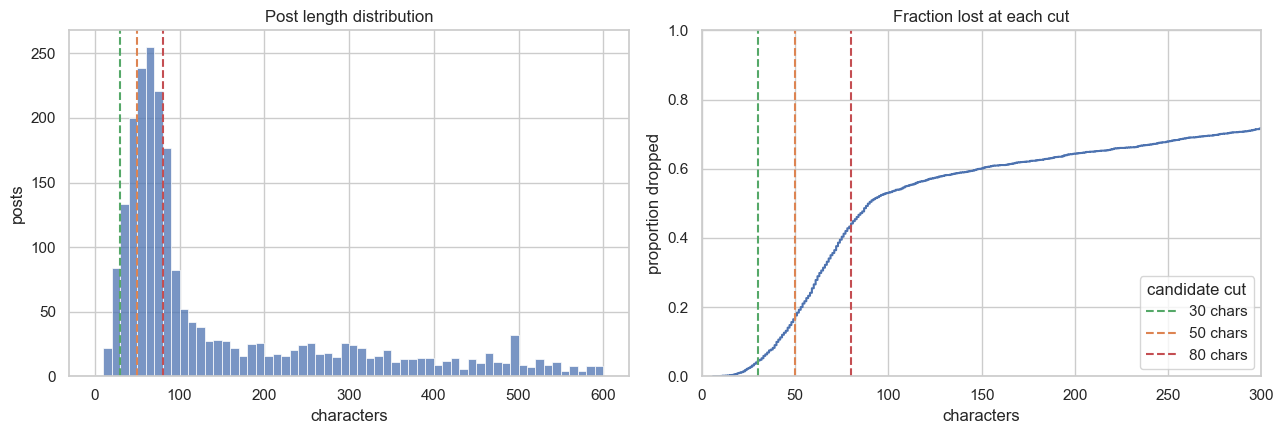

{'count': 2669.0, 'mean': 314.7, 'std': 599.8, 'min': 6.0, '25%': 59.0, '50%': 90.0, '75%': 345.0, 'max': 10109.0}
  >=   0 chars:  2669 kept  (100%)
  >=  30 chars:  2562 kept  (96%)
  >=  50 chars:  2229 kept  (84%)
  >=  80 chars:  1514 kept  (57%)
  >= 120 chars:  1161 kept  (43%)


In [25]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left — the shape: where do posts actually sit?
sns.histplot(brand["len"], bins=60, binrange=(0, 600), ax=axes[0], color="#4C72B0")
axes[0].set(title="Post length distribution", xlabel="characters", ylabel="posts")

# right — the cost: cutting at x drops this fraction
sns.ecdfplot(brand["len"], ax=axes[1], color="#4C72B0")
axes[1].set(title="Fraction lost at each cut", xlabel="characters",
            ylabel="proportion dropped", xlim=(0, 300))

for ax in axes:
    for thresh, c in zip((30, 50, 80), ("#55A868", "#DD8452", "#C44E52")):
        ax.axvline(thresh, color=c, ls="--", lw=1.5, label=f"{thresh} chars")
axes[1].legend(title="candidate cut", loc="lower right")

plt.tight_layout()
plt.show()

# keep the numbers too — the chart shows, the table confirms
print(brand["len"].describe().round(1).to_dict())
for thresh in (0, 30, 50, 80, 120):
    kept = (brand["len"] >= thresh).sum()
    print(f"  >= {thresh:>3} chars: {kept:>5} kept  ({kept/len(brand):.0%})")

In [26]:
MIN_CHARS = 30                     # set from Cell 4's table, not from habit

corpus = (brand.drop_duplicates(subset="text")
               .loc[lambda d: d["len"] >= MIN_CHARS]
               .reset_index(drop=True))
print("final corpus:", corpus.shape)

corpus["_key"] = (corpus["text"].str.lower()
                                .str.replace(r"[^a-z0-9 ]", " ", regex=True)
                                .str.replace(r"\s+", " ", regex=True)
                                .str.strip())
corpus = corpus.drop_duplicates(subset="_key").drop(columns="_key").reset_index(drop=True)

REDDIT_PROCESSED.mkdir(parents=True, exist_ok=True)
corpus.to_csv(REDDIT_BRAND, index=False)
docs = corpus["text"].tolist()

final corpus: (2462, 9)


In [27]:
m = SentenceTransformer("all-MiniLM-L6-v2")     # first run downloads from HuggingFace
print("embedder OK", m.encode(["hello"]).shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16485.28it/s]


embedder OK (1, 384)


In [28]:
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", random_state=42)

vectorizer = CountVectorizer(stop_words="english", min_df=3, ngram_range=(1, 2))

topic_model = BERTopic(umap_model=umap_model,
                       vectorizer_model=vectorizer,
                       min_topic_size=15,
                       verbose=True)

In [29]:
topics, probs = topic_model.fit_transform(docs)
corpus["topic"] = topics
n_real = len([t for t in set(topics) if t != -1])
print(f"topics: {n_real} | outliers (-1): {(corpus['topic'] == -1).sum()} of {len(corpus)}")

2026-07-20 22:53:48,236 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 77/77 [00:01<00:00, 59.44it/s]
2026-07-20 22:53:55,587 - BERTopic - Embedding - Completed ✓
2026-07-20 22:53:55,587 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-20 22:53:58,854 - BERTopic - Dimensionality - Completed ✓
2026-07-20 22:53:58,854 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-20 22:53:58,876 - BERTopic - Cluster - Completed ✓
2026-07-20 22:53:58,877 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-20 22:53:58,940 - BERTopic - Representation - Completed ✓


topics: 39 | outliers (-1): 662 of 2453


In [30]:
info = topic_model.get_topic_info()
info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,662,-1_apple_phone_samsung_iphone,"[apple, phone, samsung, iphone, like, just, ap...",[Maybe an unpopular opinion? Almost two years ...
1,0,162,0_fold_galaxy fold_galaxy_samsung galaxy,"[fold, galaxy fold, galaxy, samsung galaxy, sa...","[THE FIRST Galaxy Fold - Casey Neistat, Jennie..."
2,1,155,1_s10_battery_galaxy s10_galaxy,"[s10, battery, galaxy s10, galaxy, 5g, battery...",[Samsung Galaxy S10 5G camera review - DXOMark...
3,2,98,2_pixel_google_phone_xl,"[pixel, google, phone, xl, im, pixel xl, iphon...",[Switched from S10+ from Pixel 3XL - What I've...
4,3,93,3_buds_galaxy buds_bluetooth_galaxy,"[buds, galaxy buds, bluetooth, galaxy, bud, vo...",[Right bud 95% and other MAJOR problems Hello....
5,4,86,4_samsung galaxy_galaxy_samsung_specifications,"[samsung galaxy, galaxy, samsung, specificatio...",[Samsung Galaxy A70 Specifications and Mobile ...
6,5,77,5_apple_energy_computers_products,"[apple, energy, computers, products, apple pro...",[Some thoughts on Apple Card This project is t...
7,6,73,6_update_pie_text_messages,"[update, pie, text, messages, s8, android pie,...","[S8 One UI update still not received, why? We ..."
8,7,65,7_iphone_app_apples_new iphone,"[iphone, app, apples, new iphone, xs, 11, ipho...",[iPhone 7 Jet Black was the last great iPhone ...
9,8,60,8_airpods_wireless_wireless charging_gen,"[airpods, wireless, wireless charging, gen, ne...","[Review of AirPods gen 2 on Android, or why I'..."


In [31]:
info = topic_model.get_topic_info()
n_topics = len(info[info.Topic != -1])
outliers = int(info.loc[info.Topic == -1, "Count"].iloc[0]) if (info.Topic == -1).any() else 0
print(f"corpus: {len(corpus)} docs")
print(f"topics found: {n_topics}")
print(f"outliers (-1): {outliers}  ({outliers/len(corpus):.0%})")
print(f"in named topics: {len(corpus) - outliers}")

corpus: 2453 docs
topics found: 39
outliers (-1): 662  (27%)
in named topics: 1791


In [32]:
for t in info[info.Topic != -1]["Topic"]:
    sub = corpus[corpus["topic"] == t]
    words = ", ".join(w for w, _ in topic_model.get_topic(t)[:8])
    subs = ", ".join(f"{k}:{v}" for k, v in sub["subreddit"].value_counts().head(3).items())
    ap, sa = sub["mentions_apple"].mean(), sub["mentions_samsung"].mean()

    print(f"\n--- Topic {t}  (n={len(sub)}) ---")
    print("words :", words)
    print("subs  :", subs)
    print(f"brand : apple {ap:.0%} | samsung {sa:.0%}")
    for d in topic_model.get_representative_docs(t)[:3]:
        print("   •", d[:150].replace("\n", " "))


--- Topic 0  (n=162) ---
words : fold, galaxy fold, galaxy, samsung galaxy, samsung, handson, foldable, breaking
subs  : samsung:64, android:50, technology:27
brand : apple 2% | samsung 99%
   • THE FIRST Galaxy Fold - Casey Neistat
   • Jennie from Blackpink with the Galaxy Fold
   • Samsung Postpones Rollout of Galaxy Fold

--- Topic 1  (n=155) ---
words : s10, battery, galaxy s10, galaxy, 5g, battery life, 10, note
subs  : samsung:90, android:45, gadgets:8
brand : apple 19% | samsung 93%
   • Samsung Galaxy S10 5G camera review - DXOMark
   • S10+ 1 month later.. It's been one month since I had the S10+ and I'm just going to breifly run through everything about it   What I liked Display, Ba
   • Samsung Galaxy S10 Battery Life? I heard all these positive things about the S10+ battery life and I thought the S10 wouldn't be too far apart since i

--- Topic 2  (n=98) ---
words : pixel, google, phone, xl, im, pixel xl, iphone, just
subs  : googlepixel:85, apple:5, samsung:3
brand : app

In [33]:
TOPIC_NAMES = {
    0:  "Galaxy Fold launch & delay",
    1:  "Galaxy S10 reviews & battery life",
    2:  "Switching phones between brands",
    3:  "Galaxy Buds audio problems",
    4:  None,   # content farm — "A70 Specifications and Mobile Price" template
    5:  None,   # incoherent — Apple Card + apple-the-fruit ("animal kingdom", "Apple Auction")
    6:  "Android Pie / One UI update problems",
    7:  "iPhone models & rumours",
    8:  "AirPods reviews & Android use",
    9:  "Smartwatches: Galaxy Watch vs Apple Watch",
    10: "Galaxy Buds preorder & stock",
    11: None,   # Romanian-language YouTube spam — clustered by language, not subject
    12: "iPad models & comparisons",
    13: "MacBook keyboard & hardware",
    14: "Charging & cables",
    15: "Apple Music & streaming subscriptions",
    16: "Apple services: News+, TV+, Arcade",
    17: "Screen protection & phone durability",
    18: "Samsung TVs & home AV",
    19: "Galaxy S10 fingerprint sensor & security",
    20: None,   # r/Samsung Daily Tech Support — automated recurring thread
    21: "Apple–Qualcomm legal settlement",
    22: "Apple Card & Apple Pay",
    23: "Apple Store support & AppleCare",
    24: "Android navigation gestures",
    25: None,   # r/Android Saturday APPreciation — automated recurring thread
    26: "5G modem chip supply chain",
    27: "Galaxy Tab tablets",
    28: "Samsung corporate & market position",
    29: None,   # r/Apple Daily Tech Support — automated recurring thread
    30: "iOS development & app ecosystem",   # weakest keeper — two of three docs are promo
    31: "Samsung One UI customisation (Good Lock)",
    32: "Notification LED & edge lighting",
    33: None,   # Wallpaper Tuesday — automated recurring thread
    34: "Social app camera quality on Android",
    35: None,   # content farm — "Tips to recover lost data from [model]" template
    36: "OnePlus 6T vs Galaxy / iPhone",
    37: "iOS 13 features & dark mode",
    38: "Samsung customer service & refunds",
}

In [ ]:
# corpus keeps everything — junk and outliers get NaN, useful for the later join
corpus["topic_name"] = corpus["topic"].map(TOPIC_NAMES)
corpus.to_csv(REDDIT_TOPICS, index=False)

# results is the dashboard contract — keepers only
keep = {t: n for t, n in TOPIC_NAMES.items() if n is not None}

results = (info[info.Topic != -1][["Topic", "Count"]]
           .rename(columns={"Topic": "topic_id", "Count": "count"}))
results["topic"] = results["topic_id"].map(keep)
results = results[results["topic"].notna()].copy()      # this line is the whole fix
results["example"] = results["topic_id"].map(
    lambda t: topic_model.get_representative_docs(t)[0][:200])

results[["topic", "count", "example"]].to_csv(TOPIC_RESULTS, index=False)
print(f"{len(results)} kept, {len(TOPIC_NAMES) - len(keep)} dropped")


31 kept, 8 dropped
31 topics kept, 8 dropped as junk
1461 of 2453 docs in named topics


In [36]:
TOPIC_DIR.mkdir(parents=True, exist_ok=True)
topic_model.save(str(TOPIC_DIR), serialization="safetensors", save_ctfidf=True)

saved = sorted(p.name for p in TOPIC_DIR.iterdir())
print("saved to", TOPIC_DIR)
print(saved)

expected = {"config.json", "ctfidf.safetensors", "ctfidf_config.json",
            "topic_embeddings.safetensors", "topics.json"}
missing = expected - set(saved)
print("complete ✓" if not missing else f"MISSING: {missing}")

saved to /Users/USER/code/shreya-g01/brandparadigm/bparadigm/models/topic_model
['config.json', 'ctfidf.safetensors', 'ctfidf_config.json', 'topic_embeddings.safetensors', 'topics.json']
complete ✓


In [37]:
from bertopic import BERTopic
reloaded = BERTopic.load(str(TOPIC_DIR))
print(reloaded.get_topic(0)[:5])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 24542.03it/s]


[['fold', 0.2432000317400265], ['galaxy fold', 0.2364516592960143], ['galaxy', 0.09887693597759123], ['samsung galaxy', 0.06736831969364517], ['samsung', 0.055330012956581374]]
